In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

data = Path("./data/titanic_clean.csv")

df_i = pd.read_csv(data)
df_i.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [25]:
df_dummy= df_i[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
df_dummy.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [26]:
df_dummy.info()
df_dummy.dtypes
df_dummy.groupby("Embarked").ngroups

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    str    
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.7 KB


3

In [27]:
df_dummy = pd.get_dummies(df_dummy, columns=["Sex", "Embarked"])
df_dummy.head()



,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


In [40]:
df_dummy.loc[12,"Age":"Fare"]
# df_dummy.iloc[12,5]

# df_dummy.iloc[-1,:]


Age      20.0
SibSp       0
Parch       0
Fare     8.05
Name: 12, dtype: object

In [62]:

import time


t0 =time.perf_counter()
df_dummy["Class_Fare"] = np.where(df_dummy["Pclass"] == 1,  df_dummy["Fare"]*1.5, df_dummy["Fare"])
count_time_1 = time.perf_counter() - t0
print(f"Time taken to create Class_Fare column: {count_time_1:.6f} seconds")
df_dummy.head()

Time taken to create Class_Fare column: 0.001138 seconds


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,New_Attr,Class_Fare
0,0,3,22.0,1,0,7.2500,False,True,False,False,True,21.7500,7.25000
1,1,1,38.0,1,0,71.2833,True,False,True,False,False,71.2833,106.92495
2,1,3,26.0,0,0,7.9250,True,False,False,False,True,23.7750,7.92500
3,1,1,35.0,1,0,53.1000,True,False,False,False,True,53.1000,79.65000
4,0,3,35.0,0,0,8.0500,False,True,False,False,True,24.1500,8.05000


In [64]:
t0 = time.perf_counter()
for index, row in df_dummy.iterrows():
    if row["Pclass"] == 1:
        df_dummy.at[index, "Class_Fare"] = row["Fare"] * 1.5
    else:
        df_dummy.at[index, "Class_Fare"] = row["Fare"]
count_time_2 = time.perf_counter() - t0

t0 = time.perf_counter()
for row in df_dummy.itertuples():
    if row.Pclass == 1:
        df_dummy.at[row.Index, "Class_Fare"] = row.Fare * 1.5
    else:
        df_dummy.at[row.Index, "Class_Fare"] = row.Fare
count_time_3 = time.perf_counter() - t0 

t0 = time.perf_counter()
df_dummy["Class_Fare"] = df_dummy[df_dummy["Fare"] == 1]["Fare"] * 1.5
count_time_4 = time.perf_counter() - t0

print(f"Time taken to create Class_Fare column: {count_time_2:.6f} seconds")
print(f"Time taken using np.where: {count_time_1:.6f} seconds")
print(f"Time taken using iterrows: {count_time_2:.6f} seconds")
print(f"Time taken using itertuples: {count_time_3:.6f} seconds")
print(f"Time taken using boolean indexing: {count_time_4:.6f} seconds")
print(f"np.where is {count_time_2 / count_time_1:.2f} times faster than iterrows.")
print(f"itertuples is {count_time_2 / count_time_3:.2f} times faster than iterrows.")
print(f"Boolean indexing is {count_time_2 / count_time_4:.2f} times faster than iterrows.")

Time taken to create Class_Fare column: 0.132614 seconds
Time taken using np.where: 0.001138 seconds
Time taken using iterrows: 0.132614 seconds
Time taken using itertuples: 0.027240 seconds
Time taken using boolean indexing: 0.001180 seconds
np.where is 116.56 times faster than iterrows.
itertuples is 4.87 times faster than iterrows.
Boolean indexing is 112.41 times faster than iterrows.


In [45]:
df_dummy.info()

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_female  889 non-null    bool   
 7   Sex_male    889 non-null    bool   
 8   Embarked_C  889 non-null    bool   
 9   Embarked_Q  889 non-null    bool   
 10  Embarked_S  889 non-null    bool   
 11  New_Attr    889 non-null    float64
 12  Class_Fare  889 non-null    float64
dtypes: bool(5), float64(4), int64(4)
memory usage: 60.0 KB


<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_female  889 non-null    bool   
 7   Sex_male    889 non-null    bool   
 8   Embarked_C  889 non-null    bool   
 9   Embarked_Q  889 non-null    bool   
 10  Embarked_S  889 non-null    bool   
 11  New_Attr    889 non-null    float64
 12  Class_Fare  889 non-null    float64
dtypes: bool(5), float64(4), int64(4)
memory usage: 60.0 KB


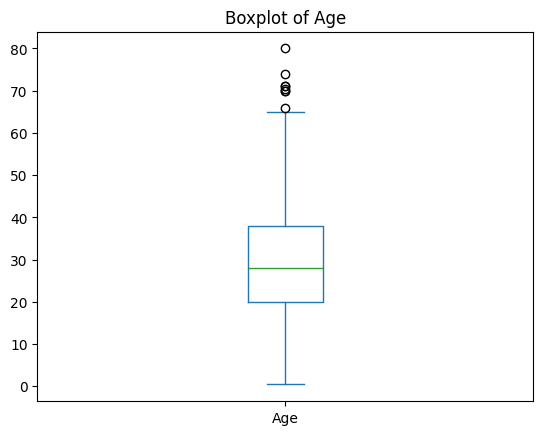

Upper bound: 65.0
Lower bound: 0


Text(0.5, 1.0, 'Boxplot of Age (0 < Age < 65)')

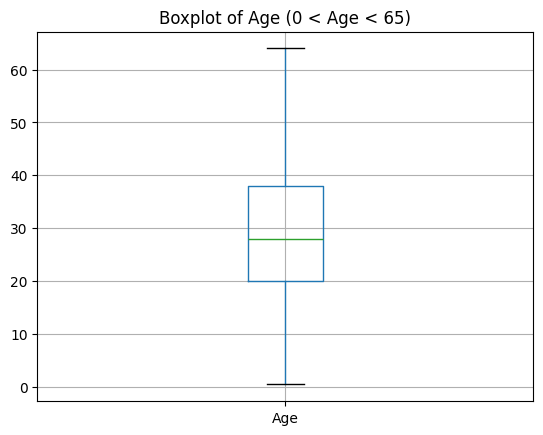

In [76]:
df_dummy["Age"].plot.box()
plt.title("Boxplot of Age")
plt.show()

q3 = df_dummy["Age"].quantile(0.75) 
q1 = df_dummy["Age"].quantile(0.25) 
iqr = q3 - q1 # interquartile range

q1,q3 = np.percentile(df_dummy["Age"], [25, 75])
iqr = q3 - q1


ub = q3 + 1.5 * (iqr)
lb = max(0, q1 - 1.5 * (iqr))

print(f"Upper bound: {ub}")
print(f"Lower bound: {lb}")
                                    
df_dummy = df_dummy[(df_dummy["Age"] < ub) & (df_dummy["Age"] > lb)]
df_dummy.boxplot(column="Age")
plt.title(f"Boxplot of Age ({lb:.0f} < Age < {ub:.0f})")


In [ ]:
df_dummy.to_csv("./data/titanic_dummy.csv", index=False)
df_dummy.to